### Analysis Notebook ###
To be run after you have run a coresponding experiement in the experiment notebook. Very similar to the plotting found in the second half of the experiements notebook, but separates onto more plots. In generall, plotting should be grouped up into a larger plotting class that can handle all of this.

In [2]:
#do necessary imports
%load_ext autoreload
%autoreload 2



from pathlib import Path

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    markers = ("pyproject.toml", ".git")
    for p in [start, *start.parents]:
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError(f"Could not find repo root from {start}")

start = Path("/home/stein/classes/REAN/notebooks") #replace with the path to your notebooks directory on your machine

REPO_ROOT = find_repo_root(start)
DATA_DIR = REPO_ROOT / "datasets"
EXPERIMENTS_DIR = REPO_ROOT / "experiments"

print("Repo root:", REPO_ROOT)

import torch
import json
from rean.models.RelaxedP4 import RelaxedP4CNN
from rean.utils.plot import LossPlot
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repo root: /home/stein/classes/REAN


In [9]:
#Copy Over the Hyperparameters you used to run the experiment you want to analyze here, so that you can use them to load the correct model and results.

group_order = 4
hidden_dim = 20 #from cohen
out_channels = hidden_dim
classes = 10
kernel_size = 3
num_gconvs = 6 #from cohen
num_epochs = 10
batch_size = 64 #leave this
learning_rate = 0.002 #0.002 is final
gamma = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Path to save experiment results. subsitute with your desired name
exp_path = EXPERIMENTS_DIR / "test_experiment_01_01_2026"

plot_path = exp_path / "plots"
plot_path.mkdir(parents=True, exist_ok=True)

#full loop
models = ['P4CNN', 'RelaxedP4CNN']
noise_types = ['none', 'iso', 'aniso']
stds = [0.1, 0.2, 0.3]

cpu


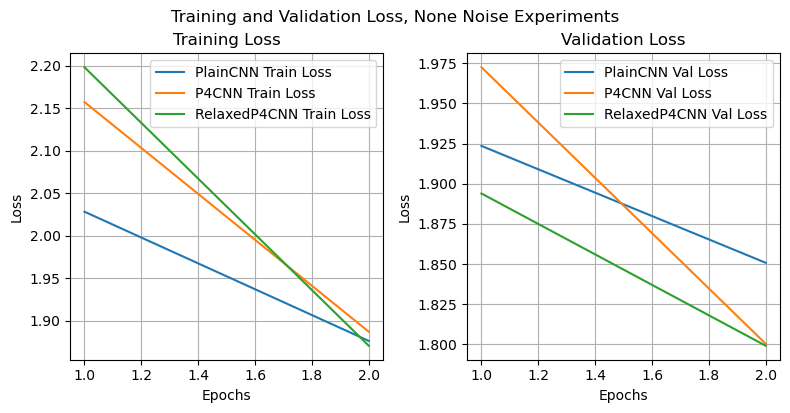

In [12]:
# do the same for each noise type, but plotting both std runs on the same axes
#so, each axes object will have 6 lines: 3 models x 2 stds
models = ['PlainCNN', 'P4CNN', 'RelaxedP4CNN']
noise_type = 'none'
fig, (train_ax, val_ax) = plt.subplots(1,2, figsize = (8, 4))
std = 0
runs = []
tests = []
for model_name in models:
    runpath = exp_path / f"runs/{model_name}_{noise_type}_std0_gamma0_lr{learning_rate}"

    #load the rundata in from the json
    rundatapath = runpath / "run_data.json"
    testdatapath = runpath / "test_data.json"
    with rundatapath.open("r", encoding="utf-8") as f:
        run_data = json.load(f)
    with testdatapath.open("r", encoding="utf-8") as f:
        test_data = json.load(f)
    run_data.update(test_data)
    runs.append(run_data)
    tests.append(test_data)

#make loss plots
train_ax = LossPlot(train_ax, runs, labels = ["model_name" ], title = "Training Loss", val = False)
val_ax = LossPlot(val_ax, runs, labels = ['model_name'], title = "Validation Loss", train = False)
fig.tight_layout()
fig.suptitle(f"Training and Validation Loss, {noise_type.capitalize()} Noise Experiments", y=1.02)
fig.savefig(plot_path / f"{noise_type}_loss_plots.png", bbox_inches="tight")


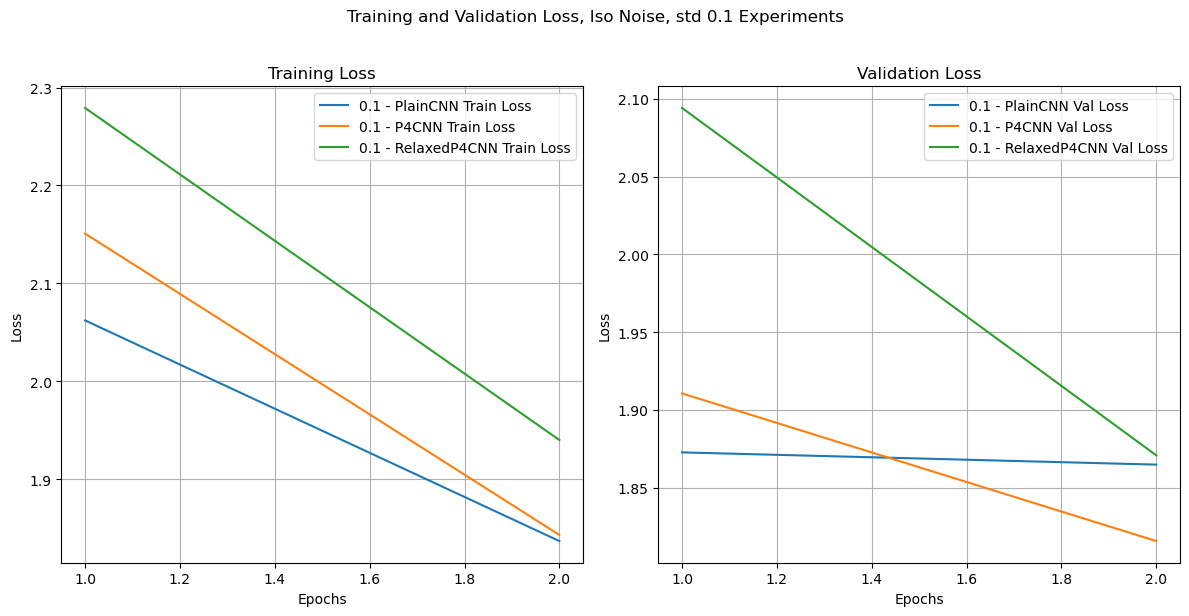

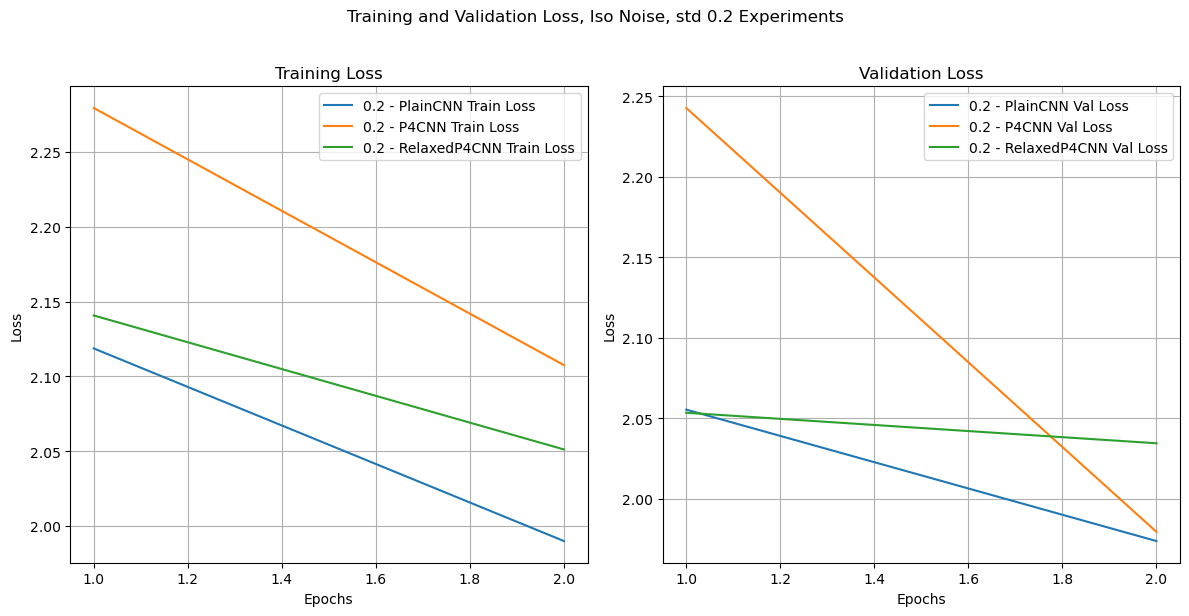

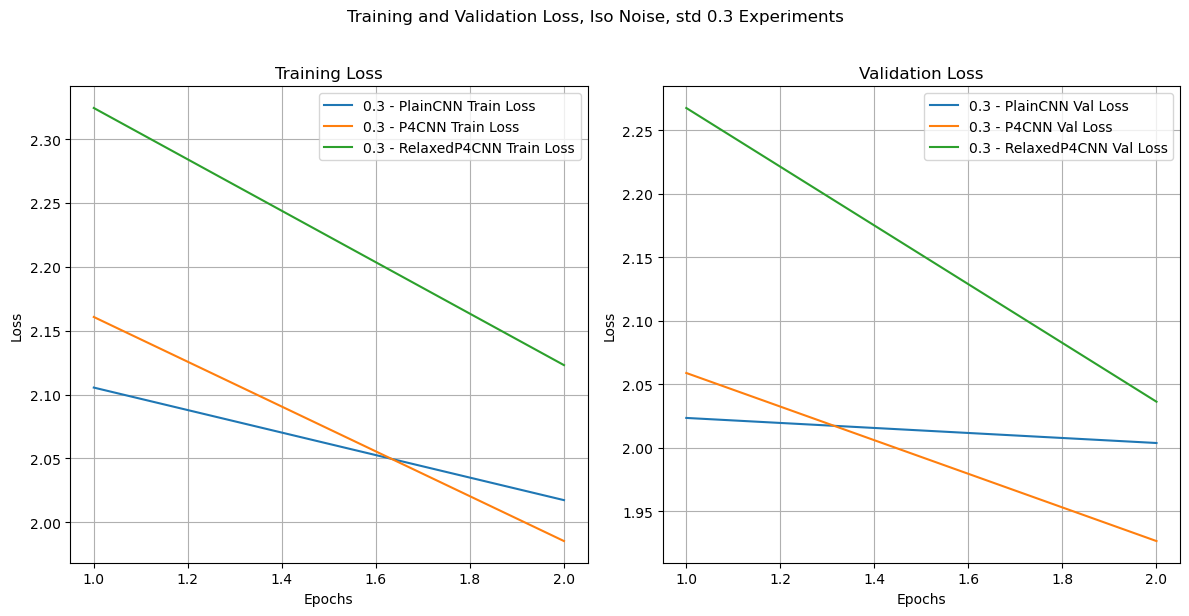

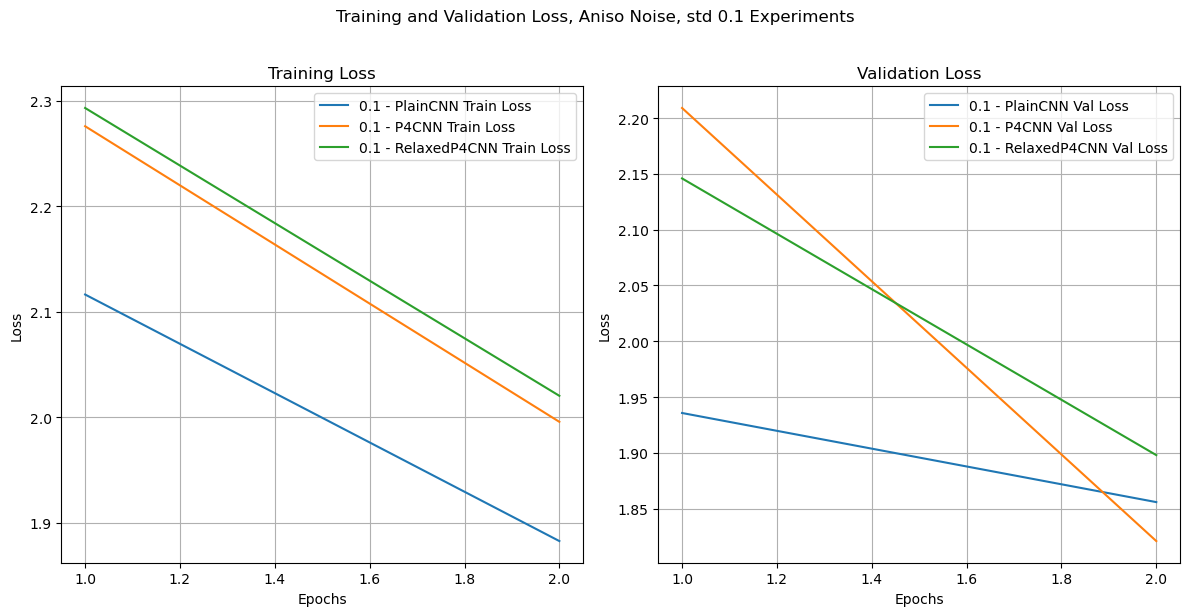

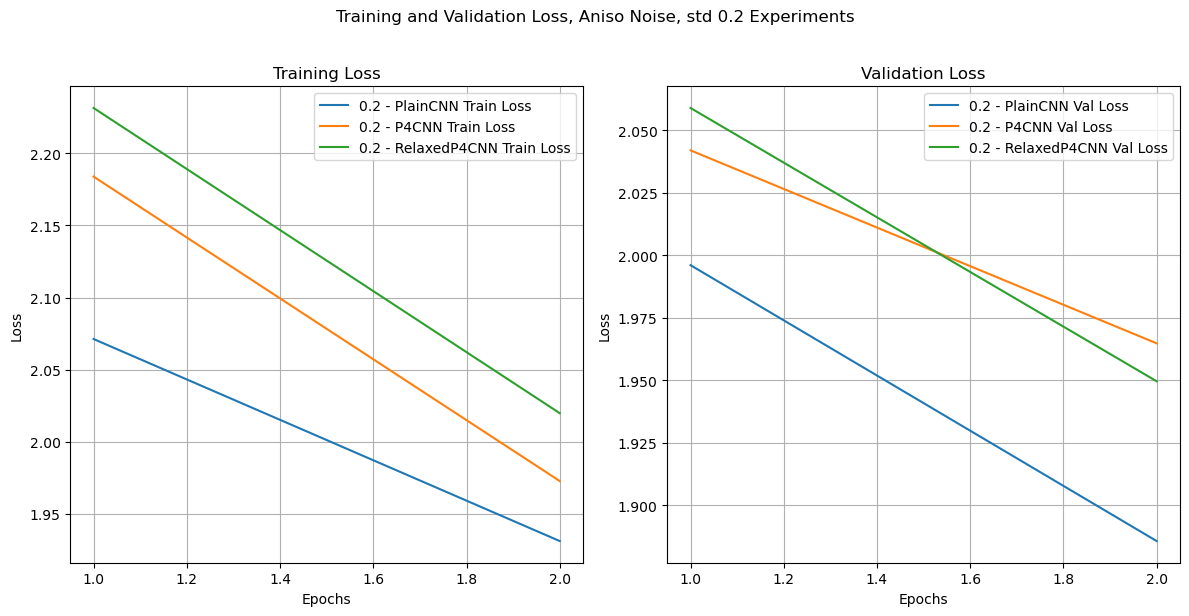

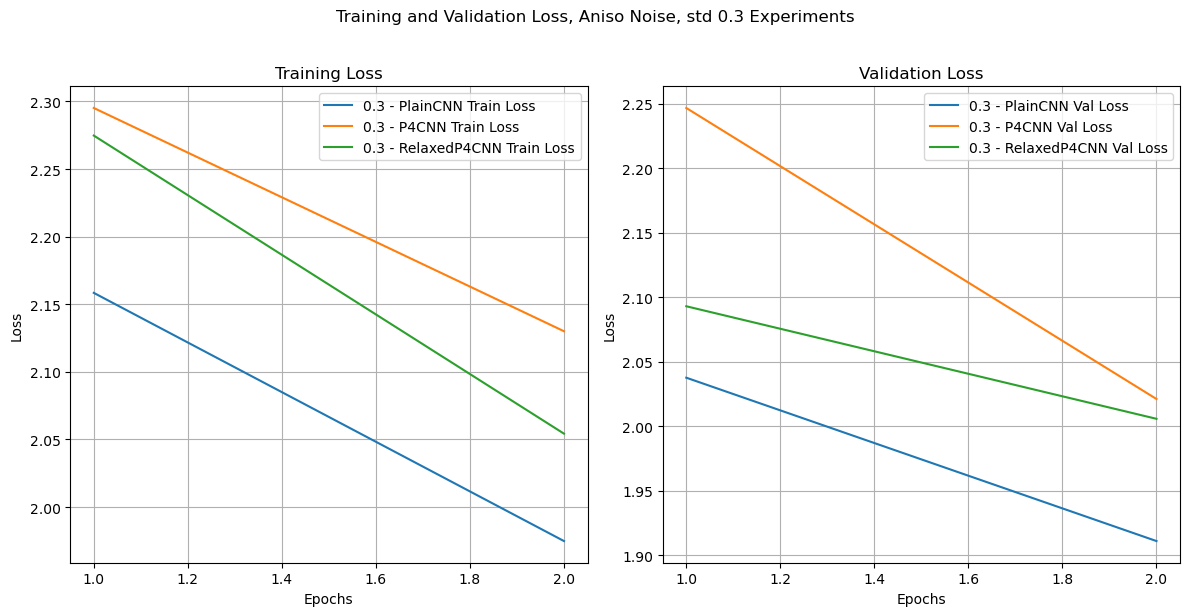

In [13]:
# do the same for each noise type, but plotting both std runs on the same axes
#so, each axes object will have 6 lines: 3 models x 2 stds
noise_types = ['iso', 'aniso']
for noise_type in noise_types:
    for std in stds:
        fig, (train_ax, val_ax) = plt.subplots(1,2, figsize = (12, 6))
        runs = []
        tests = []
        for model_name in models:
            runpath = exp_path / f"runs/{model_name}_{noise_type}_std{std}_gamma{gamma}_lr{learning_rate}"

            #load the rundata in from the json
            rundatapath = runpath / "run_data.json"
            testdatapath = runpath / "test_data.json"
            with rundatapath.open("r", encoding="utf-8") as f:
                run_data = json.load(f)
            with testdatapath.open("r", encoding="utf-8") as f:
                test_data = json.load(f)
            run_data.update(test_data)
            runs.append(run_data)
            tests.append(test_data)

        #make loss plots
        train_ax = LossPlot(train_ax, runs, labels = ["std", "model_name" ], title = "Training Loss", val = False)
        val_ax = LossPlot(val_ax, runs, labels = [ "std", 'model_name'], title = "Validation Loss", train = False)

        fig.suptitle(f"Training and Validation Loss, {noise_type.capitalize()} Noise, std {std} Experiments", y=1.02)
        fig.tight_layout()
        fig.savefig(plot_path / f"{noise_type}_std_{std}_loss_plots.png", bbox_inches="tight")


In [14]:
#finally, generate a dataframe for test accuracies across all runs
import pandas as pd
models = ['PlainCNN', 'P4CNN', 'RelaxedP4CNN']
all_runs = []
for model_name in models:
    for noise_type in noise_types + ['none']:
        for std in stds:
            if noise_type == 'none':
                if std == 0.1:
                    runpath = exp_path / f"runs/{model_name}_none_std0_gamma0_lr{learning_rate}"
                else:
                    continue
            else:
                runpath = exp_path / f"runs/{model_name}_{noise_type}_std{std}_gamma{gamma}_lr{learning_rate}"
            #load the rundata in from the json
            rundatapath = runpath / "run_data.json"
            testdatapath = runpath / "test_data.json"
            with rundatapath.open("r", encoding="utf-8") as f:
                run_data = json.load(f)
            with testdatapath.open("r", encoding="utf-8") as f:
                test_data = json.load(f)
            run_data.update(test_data)
            all_runs.append(run_data)
df = pd.DataFrame(all_runs)
df = df[['model_name', 'noise_type', 'std', 'test__noisy_acc', 'test_clean_acc']] #get only the stuff we want
# python
# reshape df so rows = (noise_type, std) and columns = (model, metric)
# expects df to have columns: 'model_name', 'noise_type', 'std', 'test_clean_acc', 'test__noisy_acc'
wide = df.pivot_table(
    index=['noise_type', 'std'],
    columns='model_name',
    values=['test_clean_acc', 'test__noisy_acc'],
    aggfunc='first'  # values are unique per run so first is fine
)

# make columns have (model, metric) order and sort
wide = wide.swaplevel(0, 1, axis=1)          # (metric, model) -> (model, metric)
wide.columns.names = ['model', 'metric']
wide = wide.sort_index(axis=1, level=0)
wide = wide.sort_index()                     # sort rows by noise_type then std
desired_models = ['PlainCNN', 'P4CNN', 'RelaxedP4CNN']
# keep only models present in the current wide DataFrame
existing = [m for m in desired_models if m in wide.columns.get_level_values(0)]

# build a list of (model, metric) tuples in the requested order
new_cols = []
for m in existing:
    metrics = list(wide[m].columns)    # metric names under each model
    for met in metrics:
        new_cols.append((m, met))

# reindex columns with the new MultiIndex ordering
wide = wide.reindex(columns=pd.MultiIndex.from_tuples(new_cols))

display(wide)

# save wide format with nested headers
wide.to_csv(plot_path / "test_accuracies_wide.csv")

PlainCNN                          P4CNN                 \
               test__noisy_acc test_clean_acc test__noisy_acc test_clean_acc   
noise_type std                                                                 
aniso      0.1           30.31          29.12           30.06          26.44   
           0.2           30.55          22.32           25.17           9.80   
           0.3           28.24          23.15           23.02          15.50   
iso        0.1           28.54          30.52           31.65           9.80   
           0.2           26.01          21.35           27.55           9.90   
           0.3           24.69          19.32           27.57           9.83   
none       0.1           28.44          28.54           33.75          33.75   

                  RelaxedP4CNN                 
               test__noisy_acc test_clean_acc  
noise_type std                                 
aniso      0.1           25.07           6.28  
           0.2           26.75           9.80  
           0.3           24.78           9.80  
iso        0.1           29.36           9.80  
           0.2           23.37          10.11  
           0.3           24.02           9.80  
none       0.1           31.94          32.44